# LAB | Intro to Machine Learning

**Load the data**

In this challenge, we will be working with Spaceship Titanic data. The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

In [46]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [47]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**Check the shape of your data**

In [48]:
#your code here
spaceship.shape

(8693, 14)

**Check for data types**

In [49]:
#your code here
spaceship.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


**Check for missing values**

In [50]:
#your code here
spaceship.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

There are multiple strategies to handle missing data

- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

For this exercise, because we have such low amount of null values, we will drop rows containing any missing value. 

In [51]:
#your code here
spaceship = spaceship.dropna() #elimina todas las filas que tengan al menos un valor vacío en cualquier columna

spaceship.shape

(6606, 14)

Explicación de por qué se eligió eliminar filas en vez de imputar valores

Se eliminan las filas con valores nulos porque la cantidad de valores faltantes por columna es pequeña en relación al total del dataset. 
Al ser tan pocos, eliminarlos no afecta significativamente al modelo y evita introducir valores 

**KNN**

K Nearest Neighbors is a distance based algorithm, and requeries all **input data to be numerical.**

Let's only select numerical columns as our features.

In [52]:
#your code here
x = spaceship.select_dtypes(include="number")

In [53]:
x.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0


And also lets define our target.

In [54]:
#your code here
y = spaceship["Transported"]

y.head()

0    False
1     True
2    False
3    False
4     True
Name: Transported, dtype: bool

**Train Test Split**

Now that we have split the data into **features** and **target** variables and imported the **train_test_split** function, split X and y into X_train, X_test, y_train, and y_test. 80% of the data should be in the training set and 20% in the test set.

In [55]:
#your code here
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [56]:
x_train.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
3432,32.0,0.0,0.0,0.0,0.0,0.0
7312,4.0,0.0,0.0,0.0,0.0,0.0
2042,30.0,0.0,236.0,0.0,1149.0,0.0
4999,17.0,13.0,0.0,565.0,367.0,1.0
5755,26.0,0.0,0.0,0.0,0.0,0.0


In [57]:
x_train.shape

(5284, 6)

In [58]:
x_test.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
2453,50.0,0.0,0.0,0.0,0.0,0.0
1334,18.0,0.0,0.0,0.0,0.0,0.0
8272,15.0,0.0,0.0,0.0,0.0,0.0
5090,52.0,0.0,0.0,0.0,0.0,0.0
4357,62.0,0.0,1633.0,0.0,1742.0,0.0


In [59]:
x_test.shape

(1322, 6)

5.284 filas para entrenar (80%)

1.322 filas para evaluar (20%)

6.606 total que coincide con el total

**Model Selection**

In this exercise we will be using **KNN** as our predictive model.

You need to choose between **Classificator** or **Regressor**. Take into consideration target variable to decide.

Initialize a KNN instance without setting any hyperparameter.

In [64]:
#your code here
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier() 

Se usa KNeighborsClassifier porque el target "Transported" es una variable binaria (True/False), lo que convierte este problema en una clasificación binaria.
La regresión se usaría si el target fuera un valor numérico continuo y en este caso no lo es

Fit the model to your data.

In [61]:
#your code here
knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Evaluate your model.

In [62]:
#your code here

print("Train accuracy:", knn.score(x_train, y_train))
print("Test accuracy:", knn.score(x_test, y_test))

Train accuracy: 0.8082891748675246
Test accuracy: 0.7655068078668684


Se usa .score() para calcular el porcentaje de predicciones correctas (porcentaje global de aciertos)

Train = 80,8% 
Test= 76,5% 

Diferencia entre train y test (4 puntos)

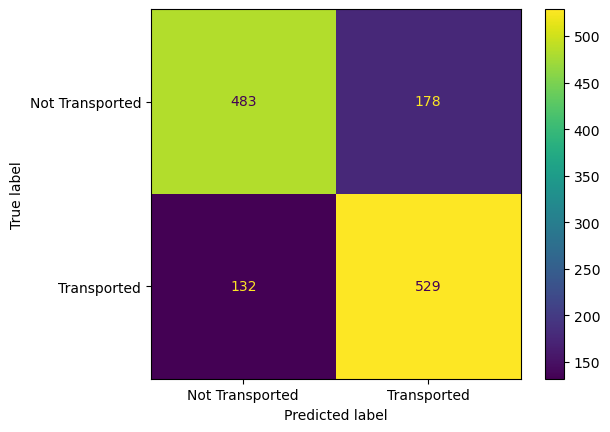

In [ ]:
# complementarmos el score() con Matrix de confusión para entender cómo se equivoca el modelo
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # para visualizar la matriz de confusión de forma gráfica

y_pred = knn.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Transported", "Transported"])
disp.plot()

La matriz nos dice lo siguiente:

483 → predijo "Not Transported" y era correcto 
529 → predijo "Transported" y era correcto 
178 → predijo "Transported" pero era "Not Transported" 
132 → predijo "Not Transported" pero era "Transported" 

Los números de la diagonal (483 y 529) son los aciertos. Los de fuera de la diagonal son los errores.

En total: 483 + 529 = 1012 aciertos sobre 1322 → que coincide  con el 76.5% de accuracy que se calculó antes

**Congratulations, you have just developed your first Machine Learning model!**